# Major Project – Project 1: House Price Prediction in Bangalore

**Student:** Shubham Sharma  
**Roll No.:** DSBA-T12/AUG-11445  
**Programme:** DSBA  
**Project Type:** Major Project  
**Domain:** Regression / Machine Learning

## Objective
Build a regression model to predict Bangalore residential property prices using property characteristics such as location, area, BHK and bathrooms.

### Models required by the project guideline
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

### Evaluation metrics
- RMSE
- MAE
- R²

The notebook also performs data cleaning, exploratory data analysis, feature engineering, outlier treatment, model comparison and interpretation of the most influential features.

## 1. Dataset

This project uses the **Bengaluru House Price Dataset**, commonly distributed through Kaggle as the Bengaluru/Bangalore House Price dataset.

The raw dataset contains fields such as `area_type`, `availability`, `location`, `size`, `society`, `total_sqft`, `bath`, `balcony`, and `price`.

> **Important:** `price_per_sqft` will be calculated for EDA/outlier analysis only. It is derived from the target `price`, so it must **not** be used as a predictive feature because that would cause target leakage.

In [28]:
# Identity / project information
print("Shubham Sharma DSBA-T12/AUG-11445")
print("Major Project - Project 1: House Price Prediction")

Shubham Sharma DSBA-T12/AUG-11445
Major Project - Project 1: House Price Prediction


In [29]:
# Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")

## 2. Load the Dataset

The following cell downloads the publicly available CSV copy of the Bengaluru House Price dataset. If your instructor specifically asks you to use a downloaded Kaggle copy, upload that CSV to Colab and replace the path in the `DATA_PATH` variable.

In [30]:
# Dataset URL (public GitHub mirror of the Kaggle Bengaluru House Price dataset)
DATA_URL = "https://raw.githubusercontent.com/abhishek-msh/Bengaluru-House-Price-Prediction/master/Bengaluru_House_Data.csv"

df = pd.read_csv(DATA_URL)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.000,1.000,39.070
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.000,3.000,120.000
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.000,3.000,62.000
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.000,1.000,95.000
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.000,1.000,51.000


In [31]:
# Basic structure
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

Columns:
['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price']

Data types:


,dtype
area_type,object
availability,object
location,object
size,object
society,object
total_sqft,object
bath,float64
balcony,float64
price,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [32]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_pct
})

display(missing_table[missing_table["Missing Values"] > 0])

,Missing Values,Missing Percentage
society,5502,41.306
balcony,609,4.572
bath,73,0.548
size,16,0.120
location,1,0.008


In [33]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())
print("Unique locations:", df["location"].nunique())
print("Unique area types:", df["area_type"].nunique())

Duplicate rows: 529
Unique locations: 1305
Unique area types: 4


## 3. Initial Data Cleaning

The dataset contains several columns that are not directly useful for a robust price-prediction model. We retain useful structural and location information while removing fields with excessive missingness or limited predictive value.

The `size` column is converted into a numeric `bhk` feature, and `total_sqft` is converted into a numeric area value. Range values such as `2100 - 2850` are represented by their midpoint.

In [34]:
# Work on a copy
data = df.copy()

# Remove exact duplicates
data = data.drop_duplicates().reset_index(drop=True)

# Convert size -> BHK
data["bhk"] = (
    data["size"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
    .astype(float)
)

# Convert total_sqft to numeric.
# For ranges such as "2100 - 2850", use the midpoint.
def convert_sqft_to_num(value):
    try:
        value = str(value).strip()
        if "-" in value:
            parts = value.split("-")
            return (float(parts[0]) + float(parts[1])) / 2
        return float(value)
    except:
        return np.nan

data["total_sqft_num"] = data["total_sqft"].apply(convert_sqft_to_num)

# Numeric conversion
data["bath"] = pd.to_numeric(data["bath"], errors="coerce")
data["balcony"] = pd.to_numeric(data["balcony"], errors="coerce")
data["price"] = pd.to_numeric(data["price"], errors="coerce")

# Normalize location text
data["location"] = (
    data["location"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Remove columns not used for modeling
data = data.drop(columns=["size", "total_sqft", "society", "availability"], errors="ignore")

# Drop rows where essential target/area fields cannot be recovered
data = data.dropna(subset=["price", "total_sqft_num", "bhk"]).reset_index(drop=True)

print("Shape after basic cleaning:", data.shape)
data.head()

Shape after basic cleaning: (12729, 7)


,area_type,location,bath,balcony,price,bhk,total_sqft_num
0,Super built-up Area,Electronic City Phase II,2.000,1.000,39.070,2.000,"1,056.000"
1,Plot Area,Chikka Tirupathi,5.000,3.000,120.000,4.000,"2,600.000"
2,Built-up Area,Uttarahalli,2.000,3.000,62.000,3.000,"1,440.000"
3,Super built-up Area,Lingadheeranahalli,3.000,1.000,95.000,3.000,"1,521.000"
4,Super built-up Area,Kothanur,2.000,1.000,51.000,2.000,"1,200.000"


In [35]:
# Rename columns for clarity
data = data.rename(columns={
    "bath": "bathrooms",
    "balcony": "balconies",
    "total_sqft_num": "total_sqft"
})

# Basic descriptive statistics
display(data.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area_type,12729,4,Super built-up Area,8306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,12729,1288,Whitefield,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bathrooms,"12,672.000",NaN,NaN,NaN,2.707,1.355,1.000,2.000,2.000,3.000,40.000
balconies,"12,144.000",NaN,NaN,NaN,1.584,0.822,0.000,1.000,2.000,2.000,3.000
price,"12,729.000",NaN,NaN,NaN,114.227,151.612,8.000,50.000,73.000,120.000,"3,600.000"
bhk,"12,729.000",NaN,NaN,NaN,2.817,1.309,1.000,2.000,3.000,3.000,43.000
total_sqft,"12,729.000",NaN,NaN,NaN,"1,568.768","1,259.896",1.000,"1,100.000","1,280.000","1,690.000","52,272.000"


## 4. Exploratory Data Analysis (EDA)

The project guideline requires at least 10 graphs. The following visualizations examine:
1. Target distribution
2. Area distribution
3. Price vs area
4. Price vs BHK
5. Price vs bathrooms
6. Average price by BHK
7. Average price by area type
8. Top locations by listing count
9. Average price by top locations
10. Correlation matrix
11. Price per square foot distribution
12. Price per square foot by BHK

The extra visualizations provide stronger evidence for the final report.

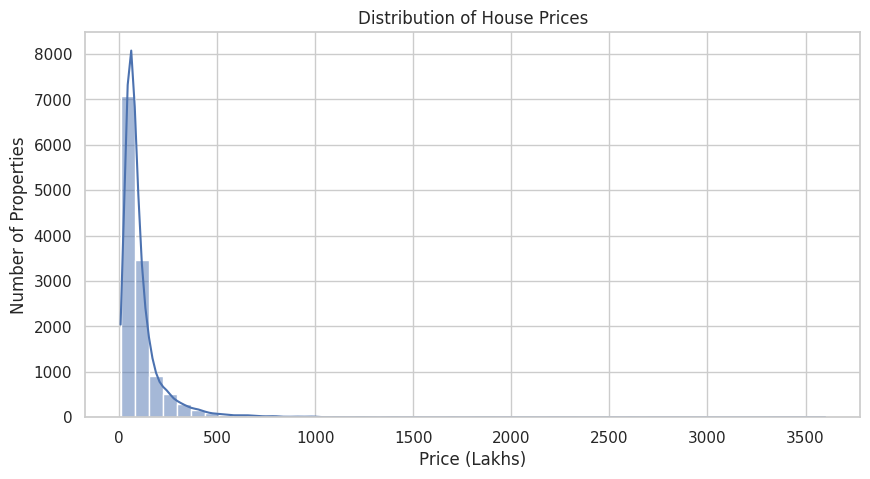

In [36]:
# EDA helper
plt.figure(figsize=(10, 5))
sns.histplot(data["price"], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Properties")
plt.show()

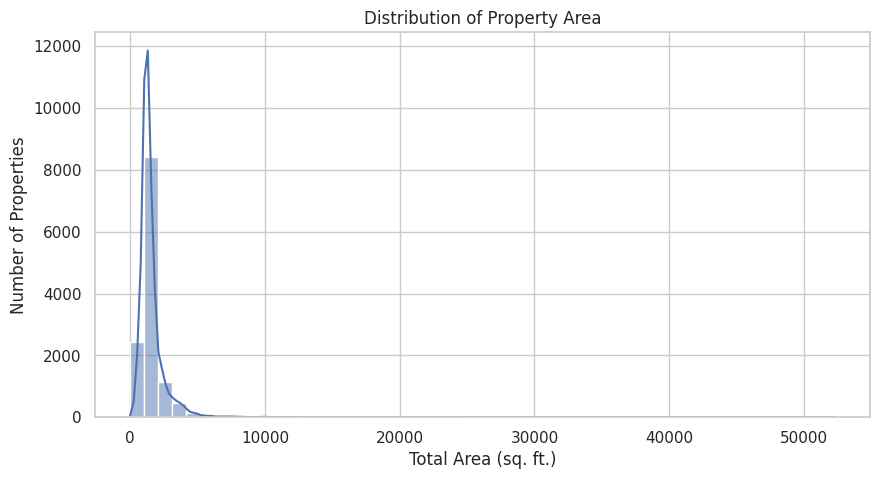

In [37]:
plt.figure(figsize=(10, 5))
sns.histplot(data["total_sqft"], bins=50, kde=True)
plt.title("Distribution of Property Area")
plt.xlabel("Total Area (sq. ft.)")
plt.ylabel("Number of Properties")
plt.show()

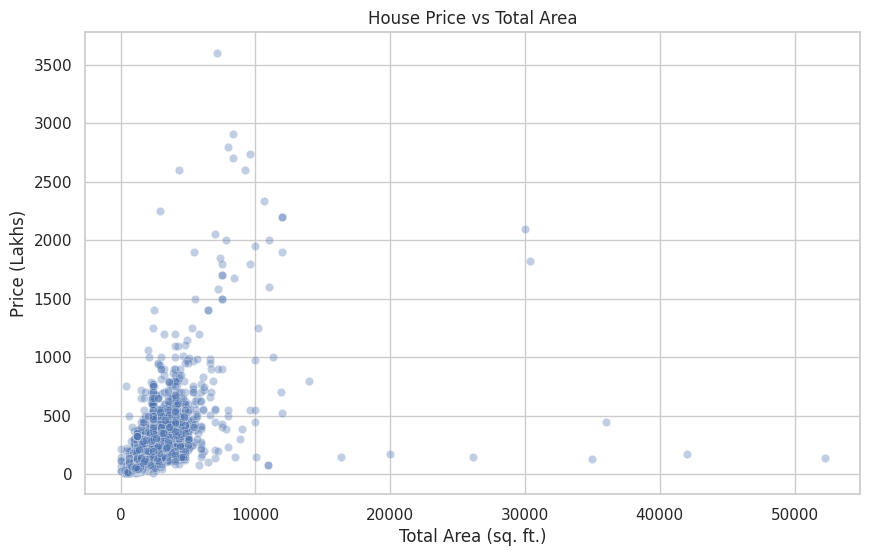

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x="total_sqft", y="price", alpha=0.35)
plt.title("House Price vs Total Area")
plt.xlabel("Total Area (sq. ft.)")
plt.ylabel("Price (Lakhs)")
plt.show()

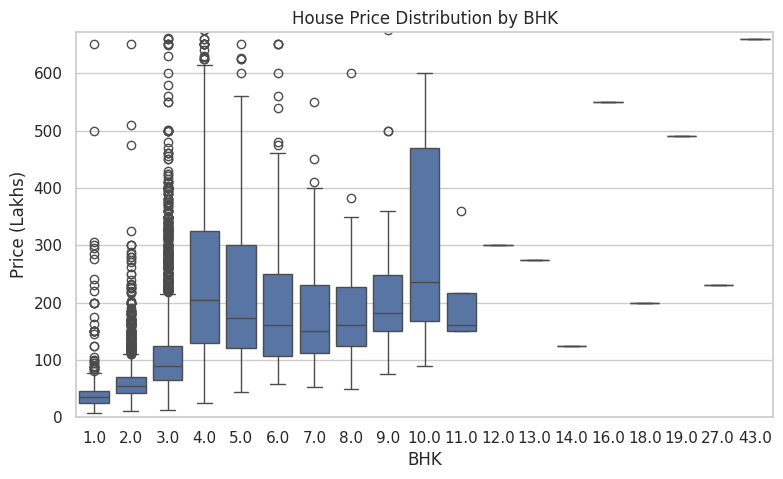

In [39]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=data, x="bhk", y="price")
plt.title("House Price Distribution by BHK")
plt.xlabel("BHK")
plt.ylabel("Price (Lakhs)")
plt.ylim(0, data["price"].quantile(0.99))
plt.show()

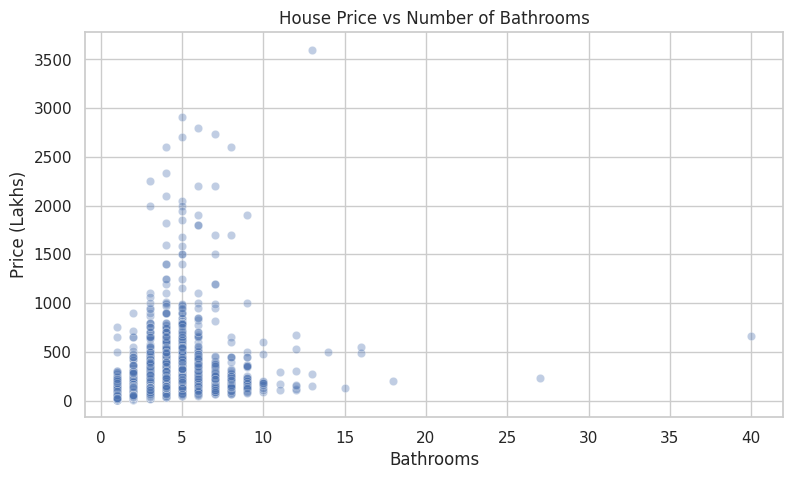

In [40]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=data, x="bathrooms", y="price", alpha=0.35)
plt.title("House Price vs Number of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price (Lakhs)")
plt.show()

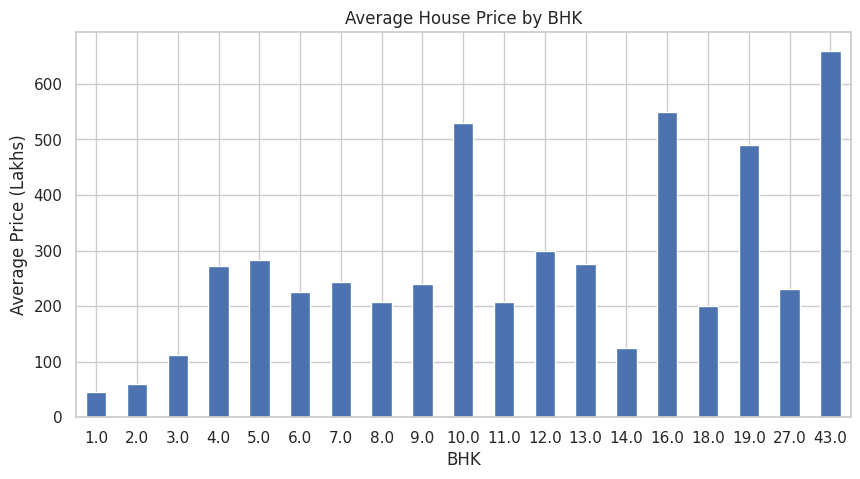

In [41]:
avg_price_bhk = data.groupby("bhk")["price"].mean().sort_index()

plt.figure(figsize=(10, 5))
avg_price_bhk.plot(kind="bar")
plt.title("Average House Price by BHK")
plt.xlabel("BHK")
plt.ylabel("Average Price (Lakhs)")
plt.xticks(rotation=0)
plt.show()

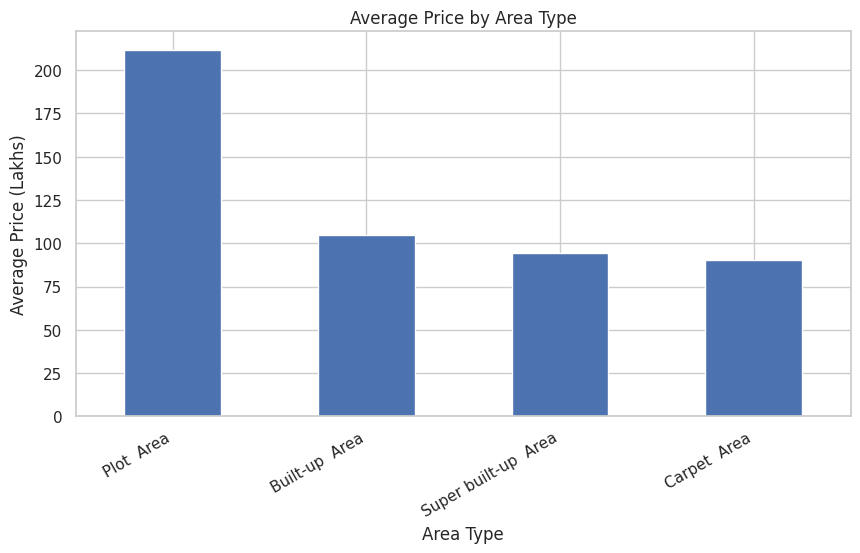

In [42]:
area_type_price = data.groupby("area_type")["price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
area_type_price.plot(kind="bar")
plt.title("Average Price by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Average Price (Lakhs)")
plt.xticks(rotation=30, ha="right")
plt.show()

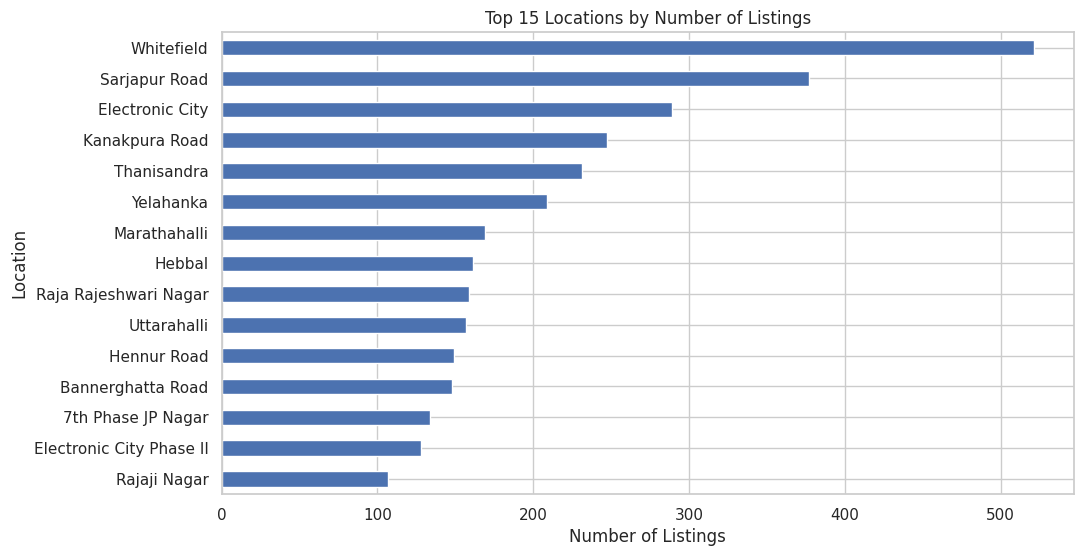

In [43]:
top_locations = data["location"].value_counts().head(15)

plt.figure(figsize=(11, 6))
top_locations.sort_values().plot(kind="barh")
plt.title("Top 15 Locations by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Location")
plt.show()

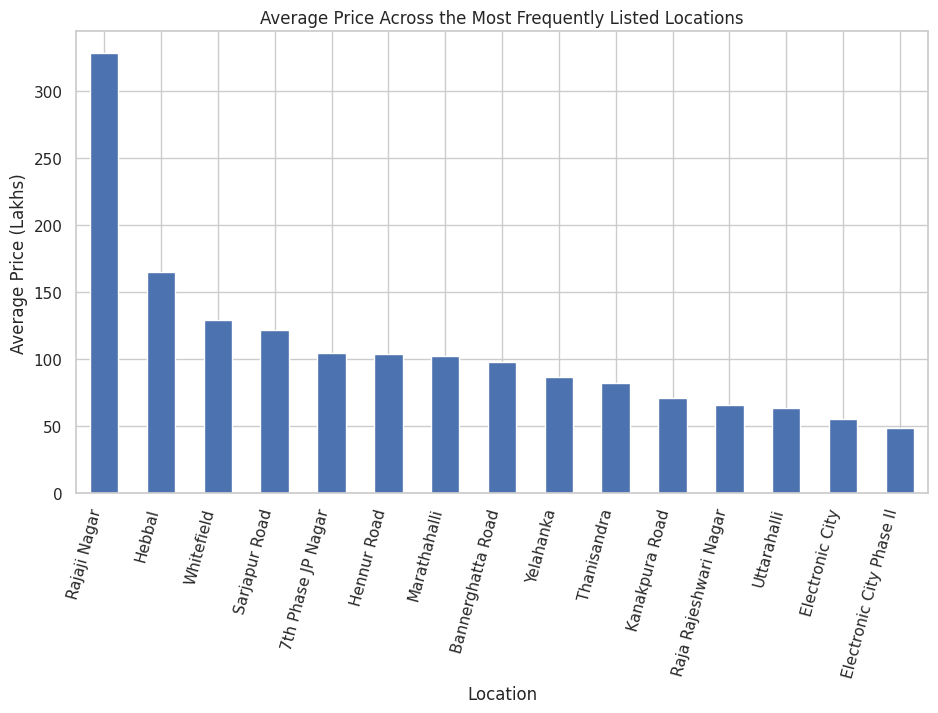

In [44]:
top_location_names = data["location"].value_counts().head(15).index
location_price = (
    data[data["location"].isin(top_location_names)]
    .groupby("location")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))
location_price.plot(kind="bar")
plt.title("Average Price Across the Most Frequently Listed Locations")
plt.xlabel("Location")
plt.ylabel("Average Price (Lakhs)")
plt.xticks(rotation=75, ha="right")
plt.show()

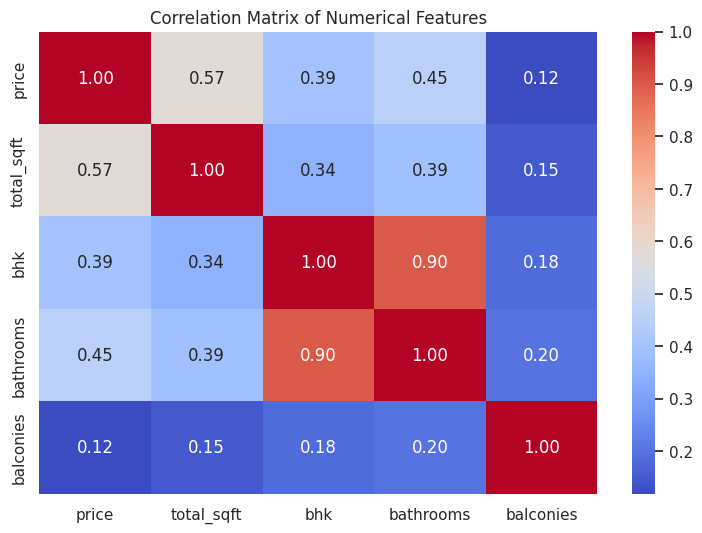

In [45]:
# Correlation matrix for numeric variables
numeric_cols = ["price", "total_sqft", "bhk", "bathrooms", "balconies"]

plt.figure(figsize=(9, 6))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

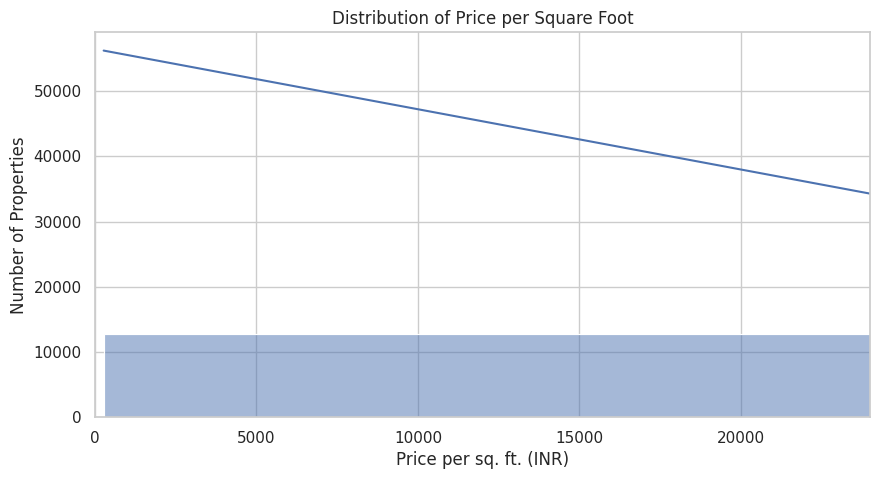

In [46]:
# Price per square foot: EDA-only feature
data["price_per_sqft"] = data["price"] * 100000 / data["total_sqft"]

plt.figure(figsize=(10, 5))
sns.histplot(data["price_per_sqft"], bins=60, kde=True)
plt.title("Distribution of Price per Square Foot")
plt.xlabel("Price per sq. ft. (INR)")
plt.ylabel("Number of Properties")
plt.xlim(0, data["price_per_sqft"].quantile(0.99))
plt.show()

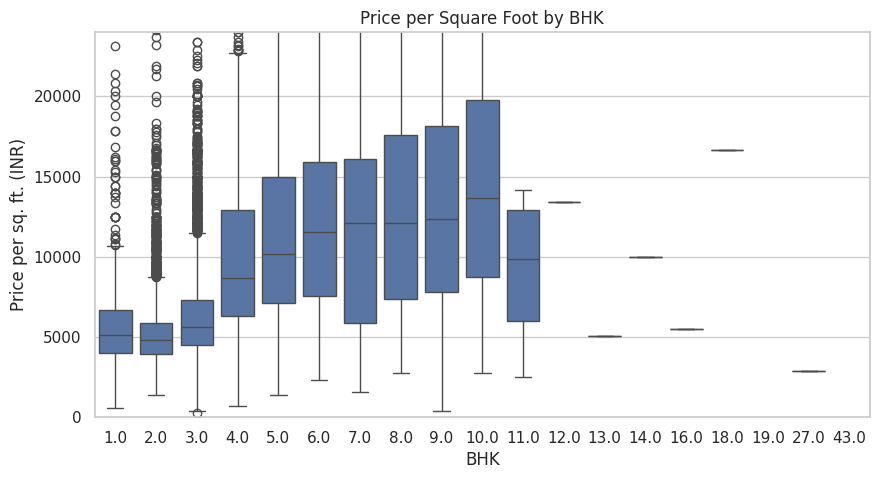

In [47]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="bhk", y="price_per_sqft")
plt.title("Price per Square Foot by BHK")
plt.xlabel("BHK")
plt.ylabel("Price per sq. ft. (INR)")
plt.ylim(0, data["price_per_sqft"].quantile(0.99))
plt.show()

## 5. Feature Engineering

New predictive features are created without using the target variable:
- `sqft_per_bhk`: available area per bedroom
- `bathrooms_per_bhk`: bathroom-to-bedroom ratio

`price_per_sqft` is retained only for EDA/outlier analysis because it is calculated from the target price and would otherwise create target leakage.

In [48]:
# Predictive feature engineering
data["sqft_per_bhk"] = data["total_sqft"] / data["bhk"]
data["bathrooms_per_bhk"] = data["bathrooms"] / data["bhk"]

# Remove impossible/invalid values
data = data[
    (data["total_sqft"] > 100) &
    (data["bhk"] > 0) &
    (data["price"] > 0)
].copy()

print("Shape after feature engineering:", data.shape)
display(data[["total_sqft", "bhk", "bathrooms", "sqft_per_bhk", "bathrooms_per_bhk", "price"]].head())

Shape after feature engineering: (12722, 10)


,total_sqft,bhk,bathrooms,sqft_per_bhk,bathrooms_per_bhk,price
0,"1,056.000",2.000,2.000,528.000,1.000,39.070
1,"2,600.000",4.000,5.000,650.000,1.250,120.000
2,"1,440.000",3.000,2.000,480.000,0.667,62.000
3,"1,521.000",3.000,3.000,507.000,1.000,95.000
4,"1,200.000",2.000,2.000,600.000,1.000,51.000


## 6. Outlier Detection and Treatment

Housing datasets often contain extreme observations. We use domain-informed rules:
- Remove properties with extremely low area per BHK.
- Remove properties with very high area per BHK.
- Remove cases with unusually many bathrooms relative to BHK.
- Use the 99th percentile of price per square foot as an additional upper-bound filter.

These rules reduce extreme observations while preserving the majority of the dataset.

In [49]:
before_outliers = len(data)

# Domain-informed outlier filters
data_clean = data[
    (data["sqft_per_bhk"] >= 300) &
    (data["sqft_per_bhk"] <= 5000) &
    (data["bathrooms"] <= data["bhk"] + 2) &
    (data["price_per_sqft"] <= data["price_per_sqft"].quantile(0.99))
].copy()

after_outliers = len(data_clean)

print("Rows before outlier treatment:", before_outliers)
print("Rows after outlier treatment :", after_outliers)
print("Rows removed                 :", before_outliers - after_outliers)
print("Percentage retained          :", round(after_outliers / before_outliers * 100, 2), "%")

Rows before outlier treatment: 12722
Rows after outlier treatment : 11825
Rows removed                 : 897
Percentage retained          : 92.95 %


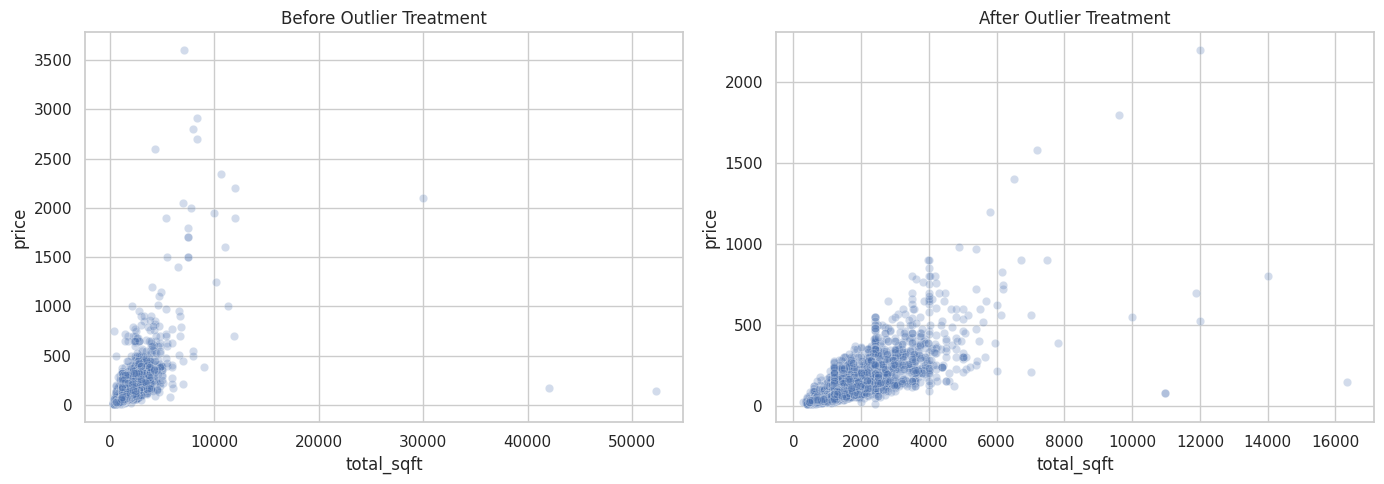

In [50]:
# Visual comparison after outlier treatment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=data.sample(min(5000, len(data)), random_state=42),
    x="total_sqft", y="price", alpha=0.25, ax=axes[0]
)
axes[0].set_title("Before Outlier Treatment")

sns.scatterplot(
    data=data_clean.sample(min(5000, len(data_clean)), random_state=42),
    x="total_sqft", y="price", alpha=0.25, ax=axes[1]
)
axes[1].set_title("After Outlier Treatment")

plt.tight_layout()
plt.show()

## 7. Prepare Data for Machine Learning

The target variable is `price`.

Categorical variables are one-hot encoded. Numerical variables are imputed using the median. A `ColumnTransformer` and `Pipeline` are used so preprocessing is learned only from the training data and consistently applied to the test data.

In [51]:
# Select model features
feature_columns = [
    "area_type",
    "location",
    "balconies",
    "total_sqft",
    "bhk",
    "bathrooms",
    "sqft_per_bhk",
    "bathrooms_per_bhk"
]

X = data_clean[feature_columns].copy()
y = data_clean["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

categorical_features = ["area_type", "location"]
numeric_features = [
    "balconies",
    "total_sqft",
    "bhk",
    "bathrooms",
    "sqft_per_bhk",
    "bathrooms_per_bhk"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 9460
Testing samples : 2365


## 8. Model 1 – Linear Regression

Linear Regression is used as the baseline regression model. It estimates the relationship between the input variables and house price by fitting a linear function.

In [52]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("RMSE:", round(linear_rmse, 3))
print("MAE :", round(linear_mae, 3))
print("R²  :", round(linear_r2, 4))

Linear Regression
RMSE: 66.377
MAE : 31.472
R²  : 0.6459


## 9. Model 2 – Decision Tree Regressor

In [53]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=12,
        min_samples_leaf=2,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree Regressor")
print("RMSE:", round(tree_rmse, 3))
print("MAE :", round(tree_mae, 3))
print("R²  :", round(tree_r2, 4))

Decision Tree Regressor
RMSE: 67.973
MAE : 30.047
R²  : 0.6286


## 10. Model 3 – Random Forest Regressor

Random Forest combines multiple decision trees and averages their predictions. This allows the model to capture nonlinear relationships between property characteristics and price.

In [54]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor")
print("RMSE:", round(rf_rmse, 3))
print("MAE :", round(rf_mae, 3))
print("R²  :", round(rf_r2, 4))

Random Forest Regressor
RMSE: 59.498
MAE : 27.197
R²  : 0.7155


## 11. Model Comparison

For RMSE and MAE, lower values indicate smaller prediction errors. For R², a value closer to 1 indicates that the model explains a larger proportion of the variance in the target.

In [55]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        rf_mae
    ],
    "R2": [
        linear_r2,
        tree_r2,
        rf_r2
    ]
}).sort_values("RMSE")

display(results.style.format({
    "RMSE": "{:.3f}",
    "MAE": "{:.3f}",
    "R2": "{:.4f}"
}))

,Model,RMSE,MAE,R2
2,Random Forest,59.498,27.197,0.7155
0,Linear Regression,66.377,31.472,0.6459
1,Decision Tree,67.973,30.047,0.6286


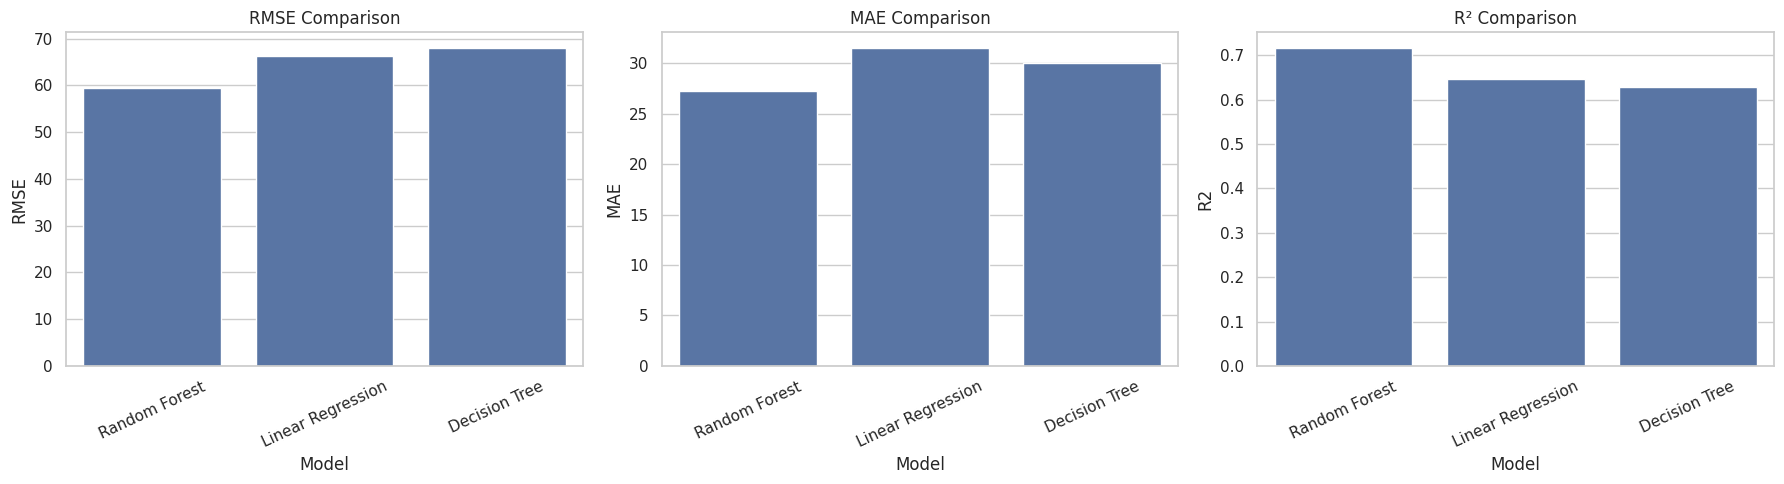

In [56]:
# Metric comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=results, x="Model", y="RMSE", ax=axes[0])
axes[0].set_title("RMSE Comparison")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=results, x="Model", y="MAE", ax=axes[1])
axes[1].set_title("MAE Comparison")
axes[1].tick_params(axis="x", rotation=25)

sns.barplot(data=results, x="Model", y="R2", ax=axes[2])
axes[2].set_title("R² Comparison")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 12. Actual vs Predicted Prices

This visualization checks how closely model predictions follow the actual house prices. Points closer to the diagonal reference line indicate smaller prediction errors.

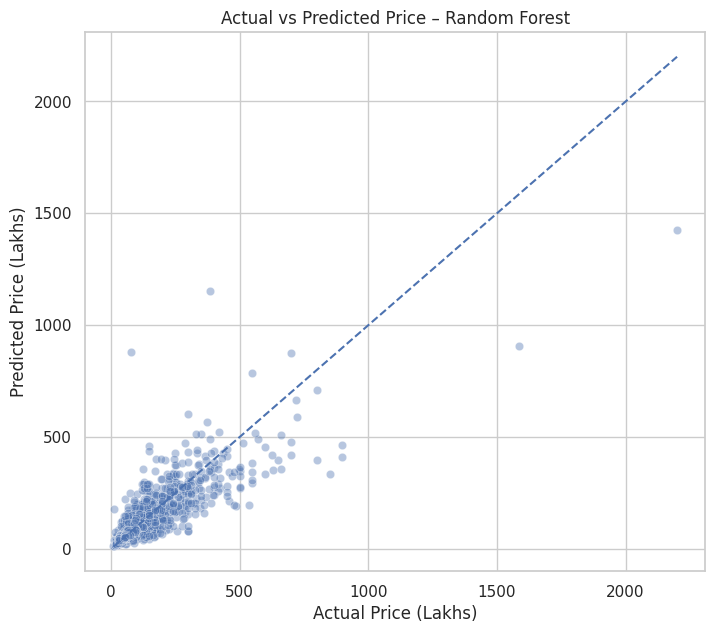

In [57]:
best_model_name = results.iloc[0]["Model"]

predictions = {
    "Linear Regression": linear_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred
}

best_pred = predictions[best_model_name]

plt.figure(figsize=(8, 7))
sns.scatterplot(x=y_test, y=best_pred, alpha=0.4)
min_value = min(y_test.min(), best_pred.min())
max_value = max(y_test.max(), best_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title(f"Actual vs Predicted Price – {best_model_name}")
plt.show()

## 13. Residual Analysis

Residuals are the differences between actual and predicted prices. A residual plot helps identify systematic prediction errors and potential heteroscedasticity.

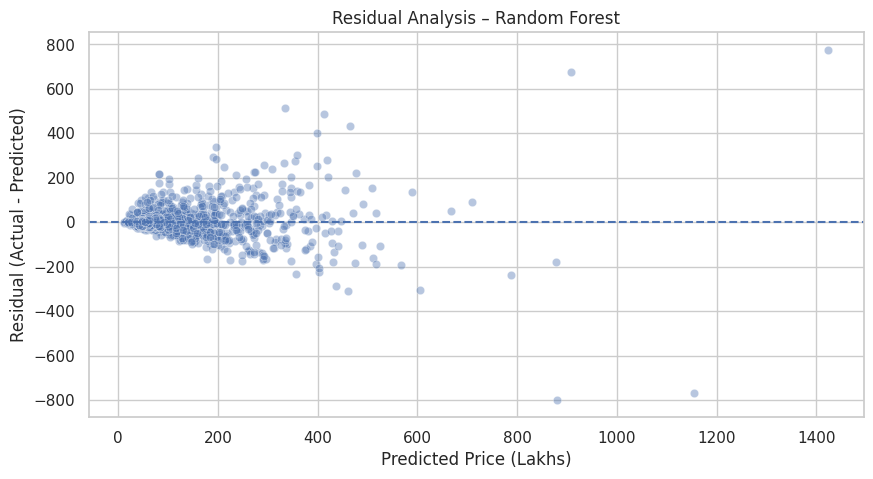

In [58]:
residuals = y_test - best_pred

plt.figure(figsize=(10, 5))
sns.scatterplot(x=best_pred, y=residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price (Lakhs)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Analysis – {best_model_name}")
plt.show()

## 14. Top 5 Features Affecting House Price

For the Random Forest model, feature importance is extracted after one-hot encoding. Because location produces many encoded columns, the importance of all encoded location categories is aggregated back to the original `location` feature so that the final interpretation is easier to explain.

In [59]:
# Fit the preprocessing transformer separately so feature names can be recovered
X_train_transformed = preprocessor.fit_transform(X_train)

rf_plain = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_plain.fit(X_train_transformed, y_train)

feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(rf_plain.feature_importances_, index=feature_names)

# Aggregate one-hot encoded features back to original columns
aggregated_importance = {}

for feature, importance in importances.items():
    clean_feature = feature.replace("num__", "").replace("cat__", "")

    if clean_feature.startswith("location_"):
        base = "location"
    elif clean_feature.startswith("area_type_"):
        base = "area_type"
    else:
        base = clean_feature

    aggregated_importance[base] = aggregated_importance.get(base, 0) + importance

top_features = (
    pd.Series(aggregated_importance)
    .sort_values(ascending=False)
    .head(5)
)

display(top_features.to_frame("Aggregated Importance"))

,Aggregated Importance
total_sqft,0.722
location,0.091
sqft_per_bhk,0.087
area_type,0.031
bathrooms,0.022


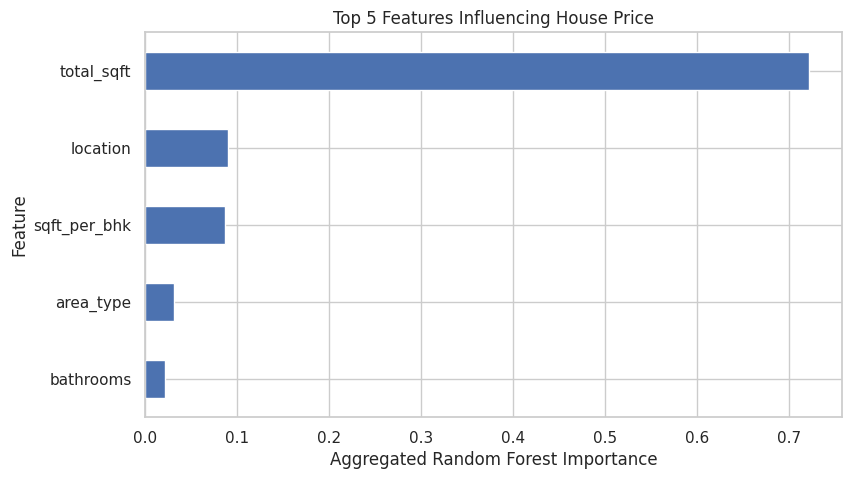

In [60]:
plt.figure(figsize=(9, 5))
top_features.sort_values().plot(kind="barh")
plt.title("Top 5 Features Influencing House Price")
plt.xlabel("Aggregated Random Forest Importance")
plt.ylabel("Feature")
plt.show()

## 15. Example Prediction

The final section demonstrates how the trained model can be used for a new property. The values below are an example input and are not part of the test set.

In [61]:
example_property = pd.DataFrame([{
    "area_type": "Super built-up  Area",
    "location": "Whitefield",
    "balconies": 2,
    "total_sqft": 1500,
    "bhk": 3,
    "bathrooms": 2,
    "sqft_per_bhk": 1500 / 3,
    "bathrooms_per_bhk": 2 / 3
}])

example_prediction = rf_model.predict(example_property)[0]

print(f"Predicted house price: ₹{example_prediction:.2f} Lakhs")

Predicted house price: ₹84.34 Lakhs


## 16. Final Findings

The final report should be written from the actual results produced above rather than from assumed accuracy values.

After running all cells, record:
- Number of original observations
- Number of observations after cleaning
- Number of observations after outlier treatment
- Linear Regression RMSE, MAE and R²
- Decision Tree RMSE, MAE and R²
- Random Forest RMSE, MAE and R²
- Top five aggregated features
- Important EDA observations

### Business Interpretation
The model can assist in estimating residential property prices from available property characteristics. Location, usable area, number of bedrooms/bathrooms and other structural attributes can be examined to understand pricing patterns. Such a system can support preliminary valuation and comparative analysis, although actual property valuation would require additional market, locality and transaction information.

### Limitations
- The dataset represents historical listings and may not represent current market prices.
- Some location categories have relatively few observations.
- Property prices are influenced by factors not captured in the dataset.
- A machine-learning estimate should not be treated as a formal property valuation.

## 17. Conclusion

This project implemented an end-to-end regression workflow for Bangalore house-price prediction. The workflow included data loading, cleaning, missing-value handling, exploratory data analysis, feature engineering, outlier treatment, categorical encoding, model training and evaluation.

Three regression algorithms—Linear Regression, Decision Tree Regressor and Random Forest Regressor—were compared using RMSE, MAE and R². The final model should be selected based on the actual test-set metrics generated in this notebook.

The analysis demonstrates how machine learning can transform structured housing data into a practical price-estimation system while highlighting the importance of preprocessing, feature engineering, outlier treatment and careful evaluation.

## References

1. Kaggle – Bengaluru House Price Dataset.
2. Scikit-learn documentation – regression models, preprocessing pipelines and evaluation metrics.
3. Project guideline: **Major Project – August 2026 Batch DSBA**.